<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/Comparaison_des_m%C3%A9thodes_d%E2%80%99optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return x[0]**2 + 10*x[1]**2

def grad_f(x):
    return np.array([2*x[0], 20*x[1]])

def hessian_f():
    return np.array([[2, 0],
                      [0, 20]])


In [3]:
# 1. Descente de gradient (pas fixe)
def gradient_descent_fixed(x0, alpha=0.05, max_iter=100):
    x = x0
    history = [x.copy()]
    for _ in range(max_iter):
        x = x - alpha * grad_f(x)
        history.append(x.copy())
    return np.array(history)

# 2. Descente de gradient (pas adaptatif)
def gradient_descent_adaptive(x0, alpha0=0.1, max_iter=100):
    x = x0
    alpha = alpha0
    history = [x.copy()]
    for k in range(1, max_iter+1):
        x = x - alpha * grad_f(x)
        alpha = alpha0 / k   # pas adaptatif
        history.append(x.copy())
    return np.array(history)

# 3. Méthode de Newton

def newton_method(x0, max_iter=10):
    x = x0
    H_inv = np.linalg.inv(hessian_f())
    history = [x.copy()]
    for _ in range(max_iter):
        x = x - H_inv @ grad_f(x)
        history.append(x.copy())
    return np.array(history)

# Point initial

x0 = np.array([3.0, 3.0])
# Exécution
gd_fixed = gradient_descent_fixed(x0)
gd_adapt = gradient_descent_adaptive(x0)
newton = newton_method(x0)

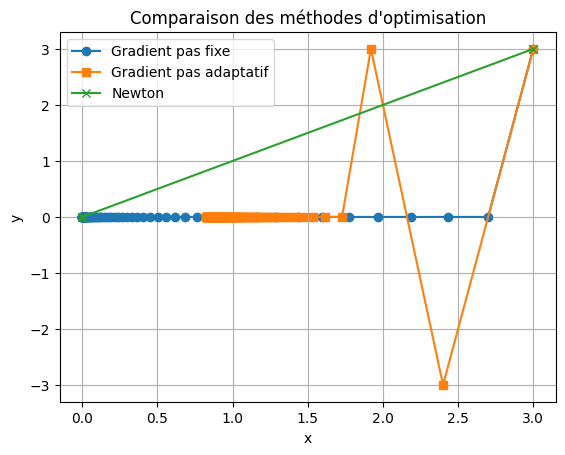

In [4]:
plt.plot(gd_fixed[:,0], gd_fixed[:,1], 'o-', label="Gradient pas fixe")
plt.plot(gd_adapt[:,0], gd_adapt[:,1], 's-', label="Gradient pas adaptatif")
plt.plot(newton[:,0], newton[:,1], 'x-', label="Newton")

plt.scatter(0, 0)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparaison des méthodes d'optimisation")
plt.legend()
plt.grid()
plt.show()